## Initializing

In [97]:
# Motor Selection - Class 1

# import statements
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import math

import MechDesign.Helpers as HM

from MechDesign.Units.Units import m_, mm_, kg_, s_, N_, rpm_, W_, h_
import MechDesign.Units.UnitMethods as UM

import MechDesign.RnM as RnM

## Classes

In [98]:
class RatioCalculation:
    """ Calculate Ratio from output speed """
    def __init__(self):
        """ Symbols defenition """ 
        self.omega_in = HM.MySymbol('omega_in', 'input rotational speed (rad/s)')
        self.v = HM.MySymbol('v', 'linear speed on output')
        self.d = HM.MySymbol('d', 'sprocket diameter')
        self.i = HM.MySymbol('i', 'ratio i_b/i_g')
        

class MotorPower:
    """ Motor Power data """
    def __init__(self):
        self.P = HM.MySymbol('P', 'power given at output')
        self.eta = HM.MySymbol('eta', 'efficiency')
        self.K_A = HM.MySymbol('K_A', 'application facotr')


## Objects

In [99]:
RC = RatioCalculation()
MP = MotorPower()

## Formulas

In [100]:
RC.omega_out = RC.v/(RC.d/2)
RC.i_total = RC.omega_in/RC.omega_out
RC.i_g = (RC.i_total/RC.i)**0.5
RC.i_b = RC.i*RC.i_g

MP.P_Motor = MP.P*MP.K_A/MP.eta


## Values

In [101]:
RC.v = 15.5*pow(10,3)*m_/h_
RC.d = 550*mm_
RC.omega_in = 1500*rpm_
RC.i = 3/5

MP.P = 8*pow(10,3)*W_
MP.eta = 0.9
MP.K_A = 1.35

## Substitution

In [102]:
RC.omega_out = HM.substitute(RC.omega_out, RC)
RC.omega_out = UM.All_to_SI(RC.omega_out)
HM.EqPrint('omega_out', RC.omega_out)

RC.i_total = HM.substitute(RC.i_total, RC)
RC.i_total = UM.All_to_SI(RC.i_total)
HM.EqPrint('i_total', RC.i_total)

RC.i_g = HM.substitute(RC.i_g, RC)
RC.i_g = UM.All_to_SI(RC.i_g)
HM.EqPrint('i_g', RC.i_g)

RC.i_b = HM.substitute(RC.i_b, RC)
RC.i_b = UM.All_to_SI(RC.i_b)
HM.EqPrint('i_b', RC.i_b)

MP.P_Motor = HM.substitute(MP.P_Motor, MP)
HM.EqPrint('P_Motor', MP.P_Motor)


Eq(omega_out, 15.66/s_)

Eq(i_total, 10.03)

Eq(i_g, 4.089)

Eq(i_b, 2.454)

Eq(P_Motor, 12000.0*W_)

Eq(P_Motor, 12000.0*W_)

## Plot

<>:13: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:13: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\parsa\AppData\Local\Temp\ipykernel_12016\3561198039.py:13: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  ax.set_xlabel('efficiency ($\eta$)')


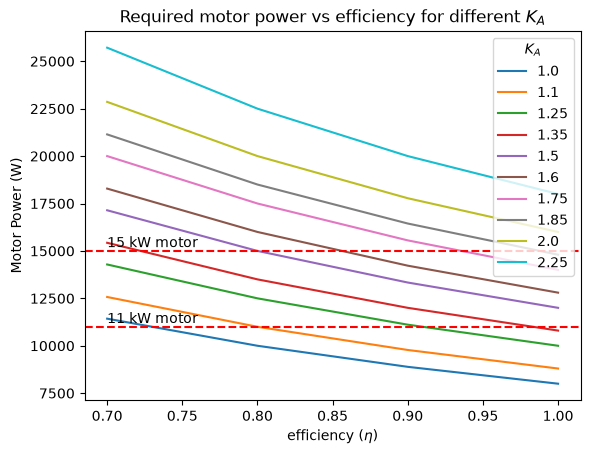

In [128]:
KA = HM.MySymbol('K_A', 'application factor')
Eta = HM.MySymbol('eta', 'efficiency')
MP.P_Motor_KA = MP.P*KA/Eta

KA_vals = [1.0, 1.1, 1.25, 1.35, 1.5, 1.6, 1.75, 1.85, 2.0, 2.25]
Eta_vals = np.arange(0.7,1,0.1)
P_vals, A, B = HM.evaluate(MP.P_Motor_KA, {'eta': Eta_vals, 'K_A': KA_vals})

fig, ax = plt.subplots()
ax.plot(Eta_vals, P_vals)
ax.legend(KA_vals, title='$K_A$', loc='upper right')
ax.set_title('Required motor power vs efficiency for different $K_A$')
ax.set_xlabel('efficiency ($\eta$)')
ax.set_ylabel('Motor Power (W)')

ax.axhline(11000, color='red', linestyle='--')
ax.axhline(15000, color='red', linestyle='--')
ax.text(0.7, 11200, '11 kW motor')
ax.text(0.7, 15200, '15 kW motor')

plt.show()
